In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:\\Users\\hp\\Downloads\\Fraud.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [6]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [30]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [7]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [31]:
df['isFlaggedFraud'].value_counts(normalize=True)

isFlaggedFraud
0    0.999997
1    0.000003
Name: proportion, dtype: float64

In [8]:
df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1
5996409,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.0,0.0,1,1
6168499,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.0,0.0,1,1
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1
6281482,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.0,0.0,1,1


In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
# pd.options.display.float_format = '{:,.0f}'.format

In [11]:
df.describe().applymap(lambda x: f'{x:,.0f}')

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620","6,362,620","6,362,620","6,362,620","6,362,620","6,362,620","6,362,620","6,362,620"
mean,243,"179,862","833,883","855,114","1,100,702","1,224,996",0,0
std,142,"603,858","2,888,243","2,924,049","3,399,180","3,674,129",0,0
min,1,0,0,0,0,0,0,0
25%,156,"13,390",0,0,0,0,0,0
50%,239,"74,872","14,208",0,"132,706","214,661",0,0
75%,335,"208,721","107,315","144,258","943,037","1,111,909",0,0
max,743,"92,445,517","59,585,040","49,585,040","356,015,889","356,179,279",1,1


In [12]:
numeric_cols = df.select_dtypes(include=np.number)

In [13]:
corr_matrix = numeric_cols.corr()


In [14]:
corr_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


In [15]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [16]:
df['change_in_balancee'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [17]:
df['change_in_balance_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [20]:
df['change'] = df['change_in_balancee'] + df['change_in_balance_dest']

In [22]:
df['change'].nunique()

5217739

In [32]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'isFraud' in numeric_cols:
    corr_with_target = df[numeric_cols].corr()['isFraud'].sort_values(ascending=False)
    print("\nNumeric features correlation with isFraud:\n", corr_with_target)
else:
    print("\n'isFraud' not found in numeric columns.")


Numeric features correlation with isFraud:
 isFraud                   1.000000
change_in_balancee        0.362472
change                    0.088369
amount                    0.076688
isFlaggedFraud            0.044109
step                      0.031578
change_in_balance_dest    0.027028
oldbalanceOrg             0.010154
newbalanceDest            0.000535
oldbalanceDest           -0.005885
newbalanceOrig           -0.008148
Name: isFraud, dtype: float64


In [34]:
df = df.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)

After dropping duplicates: (6362620, 14)


In [35]:
for c in ['nameOrig','nameDest']:
    if c in df.columns:
        print(c, "unique:", df[c].nunique(), " / rows:", df.shape[0])

nameOrig unique: 6353307  / rows: 6362620
nameDest unique: 2722362  / rows: 6362620


In [37]:
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [39]:
df['balance_difference_check'] = (df['oldbalanceOrg'] - df['newbalanceOrig']) + (df['newbalanceDest'] - df['oldbalanceDest'])

In [42]:
df['drainn'] = np.where((df['newbalanceDest']==0), 1, 0)

Text(0.5, 1.0, 'Distribution of Transaction Types')

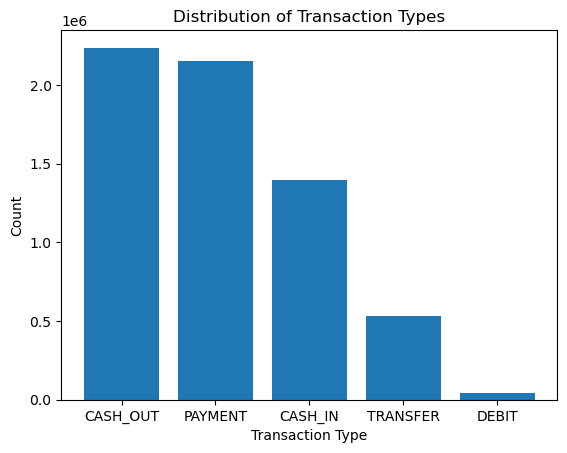

In [ ]:
plt.bar(df['type'].value_counts().index, df['type'].value_counts().values)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
plt.show()

In [53]:
df['High_risk'] = np.where(
    (df['type'] == 'TRANSFER') | (df['type'] == 'CASH_OUT'),1,0)

In [54]:
if 'amount' in df.columns:
    df['amount_log'] = np.log1p(df['amount'])
    df['is_high_amount'] = (df['amount'] > df['amount'].quantile(0.99)).astype(int)

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])


In [59]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'change_in_balancee', 'change_in_balance_dest',
       'change', 'amount_ratio', 'balance_difference_check', 'drain', 'drainn',
       'High_risk', 'amount_log', 'is_high_amount', 'type_encoded'],
      dtype='object')

In [63]:
X = df[['amount', 'oldbalanceOrg', 'newbalanceOrig',
     'oldbalanceDest', 'newbalanceDest', 
     'change_in_balancee', 'change_in_balance_dest',
       'change', 'amount_ratio', 'balance_difference_check','drainn',
       'High_risk', 'amount_log', 'is_high_amount', 'type_encoded']]
y = df['isFraud']

In [64]:
X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,change_in_balancee,change_in_balance_dest,change,amount_ratio,balance_difference_check,drainn,High_risk,amount_log,is_high_amount,type_encoded
0,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0,9839.64,0.057834,9839.64,1,0,9.194276,0,3
1,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0,1864.28,0.087731,1864.28,1,0,7.531166,0,3
2,181.00,181.0,0.00,0.0,0.0,181.00,0.0,181.00,0.994505,181.00,1,1,5.204007,0,4
3,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0,-21001.00,0.994505,-21001.00,1,1,5.204007,0,1
4,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0,11668.14,0.280788,11668.14,1,0,9.364703,0,3


In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [73]:
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])



In [ ]:
from xgboost import XGBClassifier

# Initialize model
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='auc'
)


model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=500, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [70]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # for ROC-AUC


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9991718637949011


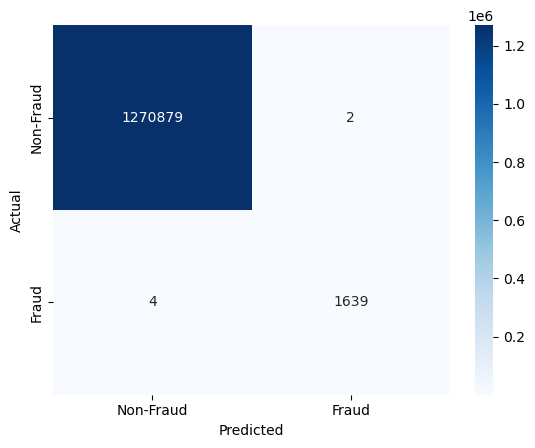

In [76]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
class_names = ['Non-Fraud', 'Fraud']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


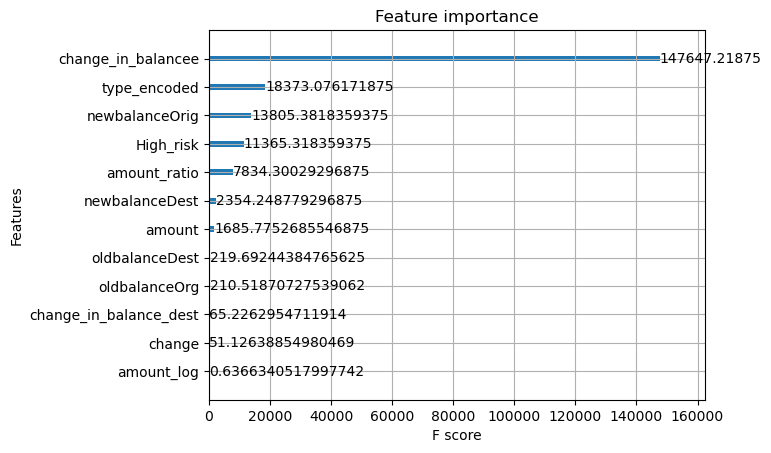

In [72]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()


1. Data cleaning including missing values, outliers and multi-collinearity.

2. Describe your fraud detection model in elaboration.

The model is a supervised classifical model, predicting whether is fraud or not.
Here, I have used tree based ensemble method XGBoost to handle the large dataset and also of model complexity. The model also uses somes new feature engineered scale for its best

3. How did you select variables to be included in the model?

I selected the variable that are going to make our model best likewise doing feature engineering of some column like oldbalance and newbalanceorg to see change to dest chnage makes me validity that change is both sides are correct.


4. Demonstrate the performance of the model by using best set of tools.

I used multiple evaluation metrices suitable for imbalanced classification
Precision - How many predicted frauds were actually fraud
Recall: How many actual frauds are detected
ROC AUC - overall ability to ditinguish fraud/no fraud
Confusion matrix- TP, FP, TN, FN

6. Do these factors make sense? If yes, How? If not, How not?

Yes, Fradusters often move large sums suddenly, causinf large balance changes
Destination accounts with unchanged balanced indicate cash out accounts
Transfer and cash out are explicitly suspicious

7. What kind of prevention should be adopted while company update its infrastructure?

By Implementing real time monitoring and alerting system based on model fraud score
Maintaining audit logs for flagged fraud cases for investigation

8. Assuming these actions have been implemented, how would you determine if they work?

By tracking model performance metrices on recent data continuously
Collect feedback from fraud analysts on flagged transactions to verify model
